<a href="https://colab.research.google.com/github/Nishi597/dry-bean-classification-streamlit/blob/main/MLAssignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install KaggleHub with pandas dataset support
!pip install -q "kagglehub[pandas-datasets]"

import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Path of the CSV file inside the Kaggle dataset
file_path = "Dry_Bean_Dataset.csv"

import os

dataset_path = "/kaggle/input/dry-bean-dataset"

print("Files in dataset:")
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

# Load the latest version directly from Kaggle

Files in dataset:


In [2]:
import kagglehub
import os

# Download/access the latest version
path = kagglehub.dataset_download(
    "muratkokludataset/dry-bean-dataset"
)

print("Dataset path:", path)

print("\nFiles found:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

100%|██████████| 4.54M/4.54M [00:01<00:00, 4.30MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/muratkokludataset/dry-bean-dataset/versions/1

Files found:
/root/.cache/kagglehub/datasets/muratkokludataset/dry-bean-dataset/versions/1/Dry_Bean_Dataset/Dry_Bean_Dataset_Citation_Request.txt
/root/.cache/kagglehub/datasets/muratkokludataset/dry-bean-dataset/versions/1/Dry_Bean_Dataset/Dry_Bean_Dataset.arff
/root/.cache/kagglehub/datasets/muratkokludataset/dry-bean-dataset/versions/1/Dry_Bean_Dataset/Dry_Bean_Dataset.xlsx


In [3]:
import pandas as pd
import os

file_path = os.path.join(
    path,
    "Dry_Bean_Dataset",
    "Dry_Bean_Dataset.xlsx"
)

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [4]:
# Basic information about the dataset

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

print("\nClass Distribution:")
print(df["Class"].value_counts())

# Remove duplicate rows

print("Shape before removing duplicates:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

Dataset Shape:
(13611, 17)

Column Names:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

Data Types:
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

Missing Values:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0

In [5]:
# Separate predictor features and target variable

X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.unique())

Feature matrix shape: (13543, 16)
Target shape: (13543,)

Target classes:
['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training feature shape: (10834, 16)
Testing feature shape: (2709, 16)

Training target shape: (10834,)
Testing target shape: (2709,)

Training class distribution:
Class
DERMASON    2837
SIRA        2109
SEKER       1621
HOROZ       1488
CALI        1304
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64

Testing class distribution:
Class
DERMASON    709
SIRA        527
SEKER       406
HOROZ       372
CALI        326
BARBUNYA    265
BOMBAY      104
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Learn scaling parameters from training data only
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to test data
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling completed successfully!
X_train_scaled shape: (10834, 16)
X_test_scaled shape: (2709, 16)


In [8]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
log_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train the model using scaled training data
log_model.fit(X_train_scaled, y_train)

# Predict classes
y_pred_log = log_model.predict(X_test_scaled)

# Predict class probabilities - required for AUC
y_prob_log = log_model.predict_proba(X_test_scaled)

print("Logistic Regression training completed.")
print("\nFirst 10 predictions:")
print(y_pred_log[:10])

Logistic Regression training completed.

First 10 predictions:
['SEKER' 'DERMASON' 'DERMASON' 'HOROZ' 'SEKER' 'DERMASON' 'DERMASON'
 'DERMASON' 'BARBUNYA' 'DERMASON']


In [9]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

# Accuracy
log_accuracy = accuracy_score(y_test, y_pred_log)

# Multiclass AUC: One-vs-Rest, weighted average
log_auc = roc_auc_score(
    y_test,
    y_prob_log,
    multi_class="ovr",
    average="weighted",
    labels=log_model.classes_
)

# Weighted metrics
log_precision = precision_score(
    y_test,
    y_pred_log,
    average="weighted"
)

log_recall = recall_score(
    y_test,
    y_pred_log,
    average="weighted"
)

log_f1 = f1_score(
    y_test,
    y_pred_log,
    average="weighted"
)

# Multiclass MCC
log_mcc = matthews_corrcoef(
    y_test,
    y_pred_log
)

print("LOGISTIC REGRESSION RESULTS")
print("--------------------------------")
print(f"Accuracy  : {log_accuracy:.4f}")
print(f"AUC Score : {log_auc:.4f}")
print(f"Precision : {log_precision:.4f}")
print(f"Recall    : {log_recall:.4f}")
print(f"F1 Score  : {log_f1:.4f}")
print(f"MCC Score : {log_mcc:.4f}")

LOGISTIC REGRESSION RESULTS
--------------------------------
Accuracy  : 0.9192
AUC Score : 0.9934
Precision : 0.9197
Recall    : 0.9192
F1 Score  : 0.9193
MCC Score : 0.9023


In [10]:
from sklearn.metrics import classification_report

print("CLASSIFICATION REPORT - LOGISTIC REGRESSION")
print("--------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_log,
        digits=4
    )
)

CLASSIFICATION REPORT - LOGISTIC REGRESSION
--------------------------------------------
              precision    recall  f1-score   support

    BARBUNYA     0.9255    0.8906    0.9077       265
      BOMBAY     1.0000    1.0000    1.0000       104
        CALI     0.9110    0.9417    0.9261       326
    DERMASON     0.9265    0.9069    0.9166       709
       HOROZ     0.9643    0.9435    0.9538       372
       SEKER     0.9296    0.9433    0.9364       406
        SIRA     0.8582    0.8843    0.8710       527

    accuracy                         0.9192      2709
   macro avg     0.9307    0.9300    0.9302      2709
weighted avg     0.9197    0.9192    0.9193      2709



In [11]:
# ==========================================
# MODEL 2: DECISION TREE CLASSIFIER
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report
)

# 1. Create the Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# 2. Train the model using unscaled training data
dt_model.fit(X_train, y_train)

# 3. Make predictions
y_pred_dt = dt_model.predict(X_test)

# 4. Predict class probabilities for AUC
y_prob_dt = dt_model.predict_proba(X_test)

# 5. Calculate evaluation metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_auc = roc_auc_score(
    y_test,
    y_prob_dt,
    multi_class="ovr",
    average="weighted",
    labels=dt_model.classes_
)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

dt_mcc = matthews_corrcoef(
    y_test,
    y_pred_dt
)

# 6. Display results
print("DECISION TREE RESULTS")
print("--------------------------------")
print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"AUC Score : {dt_auc:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1 Score  : {dt_f1:.4f}")
print(f"MCC Score : {dt_mcc:.4f}")

# 7. Classification Report
print("\nCLASSIFICATION REPORT - DECISION TREE")
print("--------------------------------------------")
print(
    classification_report(
        y_test,
        y_pred_dt,
        digits=4
    )
)

DECISION TREE RESULTS
--------------------------------
Accuracy  : 0.8966
AUC Score : 0.9363
Precision : 0.8965
Recall    : 0.8966
F1 Score  : 0.8964
MCC Score : 0.8750

CLASSIFICATION REPORT - DECISION TREE
--------------------------------------------
              precision    recall  f1-score   support

    BARBUNYA     0.8787    0.9019    0.8901       265
      BOMBAY     1.0000    1.0000    1.0000       104
        CALI     0.9052    0.9080    0.9066       326
    DERMASON     0.8881    0.9069    0.8974       709
       HOROZ     0.9526    0.9194    0.9357       372
       SEKER     0.9135    0.9360    0.9246       406
        SIRA     0.8383    0.8065    0.8221       527

    accuracy                         0.8966      2709
   macro avg     0.9109    0.9112    0.9109      2709
weighted avg     0.8965    0.8966    0.8964      2709



In [12]:
# ==========================================
# MODEL 3: K-NEAREST NEIGHBORS (kNN)
# ==========================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report
)

# 1. Create kNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# 2. Train using SCALED training data
knn_model.fit(X_train_scaled, y_train)

# 3. Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# 4. Predict probabilities for AUC
y_prob_knn = knn_model.predict_proba(X_test_scaled)

# 5. Calculate evaluation metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)

knn_auc = roc_auc_score(
    y_test,
    y_prob_knn,
    multi_class="ovr",
    average="weighted",
    labels=knn_model.classes_
)

knn_precision = precision_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

knn_recall = recall_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

knn_mcc = matthews_corrcoef(
    y_test,
    y_pred_knn
)

# 6. Display results
print("K-NEAREST NEIGHBORS RESULTS")
print("--------------------------------")
print(f"Accuracy  : {knn_accuracy:.4f}")
print(f"AUC Score : {knn_auc:.4f}")
print(f"Precision : {knn_precision:.4f}")
print(f"Recall    : {knn_recall:.4f}")
print(f"F1 Score  : {knn_f1:.4f}")
print(f"MCC Score : {knn_mcc:.4f}")

# 7. Classification Report
print("\nCLASSIFICATION REPORT - kNN")
print("--------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_knn,
        digits=4
    )
)

K-NEAREST NEIGHBORS RESULTS
--------------------------------
Accuracy  : 0.9155
AUC Score : 0.9811
Precision : 0.9163
Recall    : 0.9155
F1 Score  : 0.9157
MCC Score : 0.8978

CLASSIFICATION REPORT - kNN
--------------------------------------------
              precision    recall  f1-score   support

    BARBUNYA     0.9317    0.8755    0.9027       265
      BOMBAY     1.0000    1.0000    1.0000       104
        CALI     0.8983    0.9479    0.9224       326
    DERMASON     0.9151    0.9126    0.9138       709
       HOROZ     0.9612    0.9328    0.9468       372
       SEKER     0.9476    0.9360    0.9418       406
        SIRA     0.8490    0.8748    0.8617       527

    accuracy                         0.9155      2709
   macro avg     0.9290    0.9256    0.9270      2709
weighted avg     0.9163    0.9155    0.9157      2709



In [13]:
# ==========================================
# MODEL 4: GAUSSIAN NAIVE BAYES
# ==========================================

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report
)

# 1. Create Gaussian Naive Bayes model
nb_model = GaussianNB()

# 2. Train using original (unscaled) training data
nb_model.fit(X_train, y_train)

# 3. Make class predictions
y_pred_nb = nb_model.predict(X_test)

# 4. Predict class probabilities for AUC
y_prob_nb = nb_model.predict_proba(X_test)

# 5. Calculate evaluation metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)

nb_auc = roc_auc_score(
    y_test,
    y_prob_nb,
    multi_class="ovr",
    average="weighted",
    labels=nb_model.classes_
)

nb_precision = precision_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

nb_recall = recall_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

nb_mcc = matthews_corrcoef(
    y_test,
    y_pred_nb
)

# 6. Display results
print("GAUSSIAN NAIVE BAYES RESULTS")
print("--------------------------------")
print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"AUC Score : {nb_auc:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1 Score  : {nb_f1:.4f}")
print(f"MCC Score : {nb_mcc:.4f}")

# 7. Classification Report
print("\nCLASSIFICATION REPORT - GAUSSIAN NAIVE BAYES")
print("--------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_nb,
        digits=4
    )
)

GAUSSIAN NAIVE BAYES RESULTS
--------------------------------
Accuracy  : 0.7630
AUC Score : 0.9644
Precision : 0.7647
Recall    : 0.7630
F1 Score  : 0.7607
MCC Score : 0.7143

CLASSIFICATION REPORT - GAUSSIAN NAIVE BAYES
--------------------------------------------
              precision    recall  f1-score   support

    BARBUNYA     0.6778    0.4604    0.5483       265
      BOMBAY     1.0000    1.0000    1.0000       104
        CALI     0.6878    0.8313    0.7528       326
    DERMASON     0.8703    0.8237    0.8464       709
       HOROZ     0.7804    0.7930    0.7867       372
       SEKER     0.6690    0.6970    0.6828       406
        SIRA     0.7299    0.7742    0.7514       527

    accuracy                         0.7630      2709
   macro avg     0.7736    0.7685    0.7669      2709
weighted avg     0.7647    0.7630    0.7607      2709



In [14]:
# ==========================================
# MODEL 5: RANDOM FOREST CLASSIFIER
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report
)

# 1. Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# 2. Train using original (unscaled) training data
rf_model.fit(X_train, y_train)

# 3. Make predictions
y_pred_rf = rf_model.predict(X_test)

# 4. Predict class probabilities for AUC
y_prob_rf = rf_model.predict_proba(X_test)

# 5. Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf,
    multi_class="ovr",
    average="weighted",
    labels=rf_model.classes_
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_mcc = matthews_corrcoef(
    y_test,
    y_pred_rf
)

# 6. Display results
print("RANDOM FOREST RESULTS")
print("--------------------------------")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"AUC Score : {rf_auc:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"MCC Score : {rf_mcc:.4f}")

# 7. Classification Report
print("\nCLASSIFICATION REPORT - RANDOM FOREST")
print("--------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_rf,
        digits=4
    )
)

RANDOM FOREST RESULTS
--------------------------------
Accuracy  : 0.9199
AUC Score : 0.9907
Precision : 0.9199
Recall    : 0.9199
F1 Score  : 0.9198
MCC Score : 0.9031

CLASSIFICATION REPORT - RANDOM FOREST
--------------------------------------------
              precision    recall  f1-score   support

    BARBUNYA     0.9331    0.8943    0.9133       265
      BOMBAY     1.0000    1.0000    1.0000       104
        CALI     0.9217    0.9387    0.9301       326
    DERMASON     0.9097    0.9238    0.9167       709
       HOROZ     0.9643    0.9435    0.9538       372
       SEKER     0.9351    0.9581    0.9465       406
        SIRA     0.8671    0.8539    0.8604       527

    accuracy                         0.9199      2709
   macro avg     0.9330    0.9303    0.9315      2709
weighted avg     0.9199    0.9199    0.9198      2709



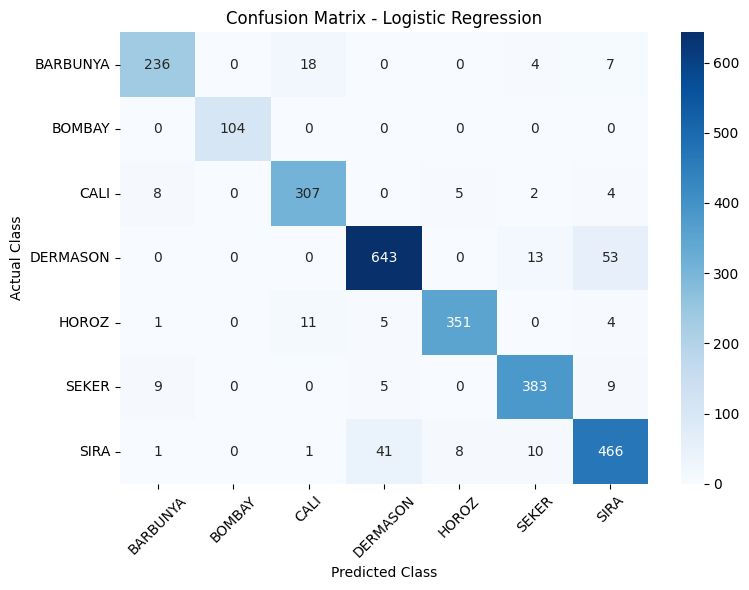

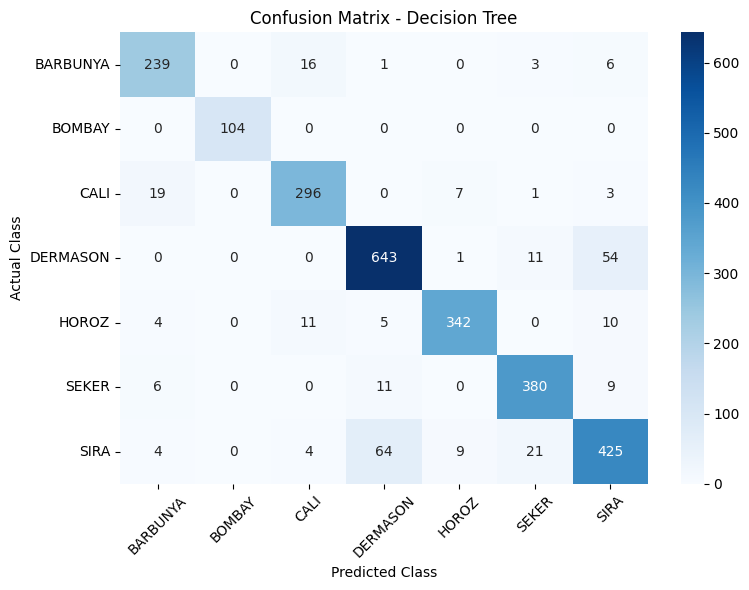

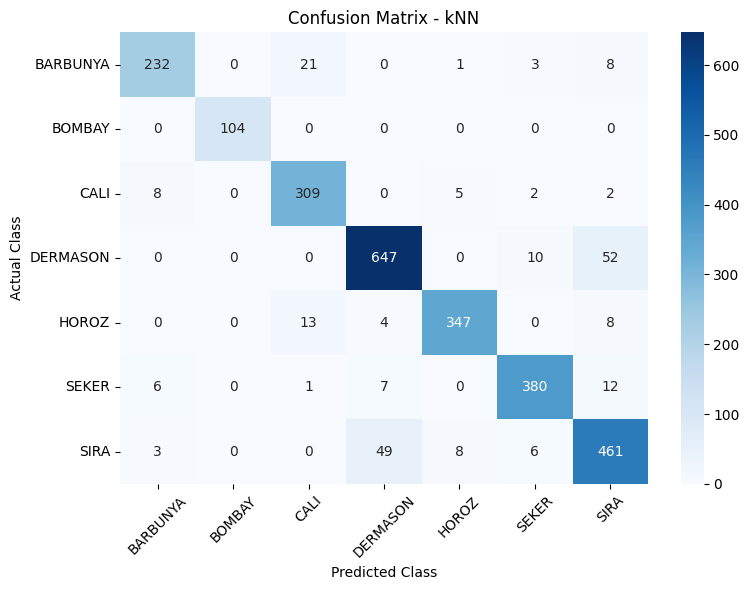

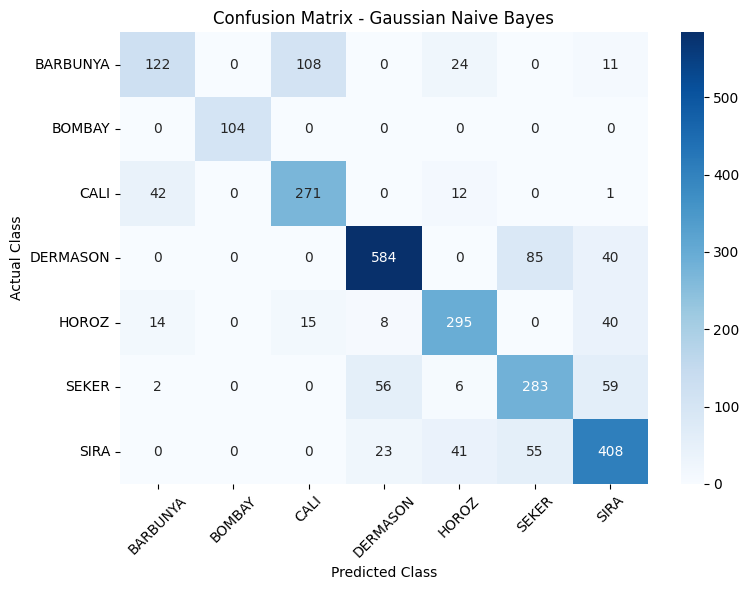

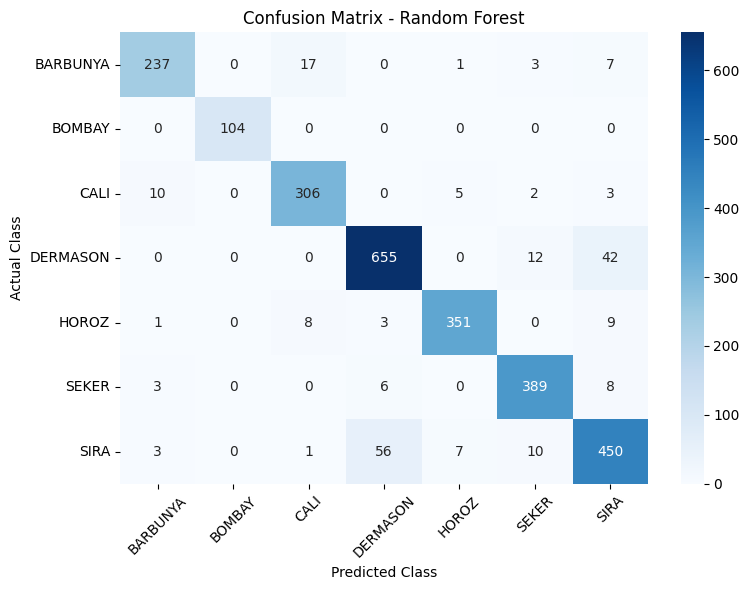

In [15]:
# ==========================================
# CONFUSION MATRICES FOR ALL MODELS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Models and their predictions
model_predictions = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_dt,
    "kNN": y_pred_knn,
    "Gaussian Naive Bayes": y_pred_nb,
    "Random Forest": y_pred_rf
}

# Use the same class order for every confusion matrix
class_names = sorted(y_test.unique())

# Generate one confusion matrix for each model
for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=class_names
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [16]:
# ==========================================
# SAVE TEST DATA FOR STREAMLIT
# ==========================================

# Create a copy of the test features
test_data = X_test.copy()

# Add the actual target class
test_data["Class"] = y_test.values

# Save as CSV
test_data.to_csv("test_data.csv", index=False)

print("test_data.csv saved successfully!")
print("Shape:", test_data.shape)

display(test_data.head())

test_data.csv saved successfully!
Shape: (2709, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
1223,40512,737.636,248.202030,208.525152,1.190274,0.542365,40973,227.115566,0.744268,0.988749,0.935641,0.915043,0.006127,0.002650,0.837304,0.996621,SEKER
11769,31890,660.655,250.417300,162.522502,1.540816,0.760783,32240,201.503372,0.801962,0.989144,0.918153,0.804670,0.007853,0.002031,0.647494,0.997670,DERMASON
12059,33107,671.869,244.728317,172.938116,1.415121,0.707560,33506,205.312303,0.798683,0.988092,0.921638,0.838940,0.007392,0.002259,0.703820,0.995990,DERMASON
7126,61684,984.878,412.115648,191.473280,2.152340,0.885515,62303,280.247227,0.784724,0.990065,0.799130,0.680021,0.006681,0.000881,0.462428,0.995303,HOROZ
638,37189,700.253,243.343401,194.910062,1.248491,0.598708,37534,217.601713,0.784826,0.990808,0.953047,0.894217,0.006543,0.002581,0.799623,0.998322,SEKER


In [17]:
# ==========================================
# SAVE TRAINED MODELS AND SCALER
# ==========================================

import joblib
import os

# Create model directory
os.makedirs("model", exist_ok=True)

# Save all trained models
joblib.dump(log_model, "model/logistic_regression.pkl")
joblib.dump(dt_model, "model/decision_tree.pkl")
joblib.dump(knn_model, "model/knn.pkl")
joblib.dump(nb_model, "model/naive_bayes.pkl")
joblib.dump(rf_model, "model/random_forest.pkl")

# Save scaler used by Logistic Regression and kNN
joblib.dump(scaler, "model/scaler.pkl")

print("All models and scaler saved successfully!")

print("\nFiles inside model folder:")
print(os.listdir("model"))

All models and scaler saved successfully!

Files inside model folder:
['scaler.pkl', 'logistic_regression.pkl', 'random_forest.pkl', 'naive_bayes.pkl', 'decision_tree.pkl', 'knn.pkl']


In [18]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="Dry Bean Classification",
    page_icon="🫘",
    layout="wide"
)

st.title("🫘 Dry Bean Classification")
st.write(
    "Upload the test dataset and select a machine learning model "
    "to evaluate its classification performance."
)

# --------------------------------------------------
# LOAD MODELS
# --------------------------------------------------

@st.cache_resource
def load_models():

    models = {
        "Logistic Regression":
            joblib.load("model/logistic_regression.pkl"),

        "Decision Tree":
            joblib.load("model/decision_tree.pkl"),

        "k-Nearest Neighbors (kNN)":
            joblib.load("model/knn.pkl"),

        "Gaussian Naive Bayes":
            joblib.load("model/naive_bayes.pkl"),

        "Random Forest":
            joblib.load("model/random_forest.pkl")
    }

    scaler = joblib.load("model/scaler.pkl")

    return models, scaler


models, scaler = load_models()

# --------------------------------------------------
# SIDEBAR
# --------------------------------------------------

st.sidebar.header("Model Selection")

selected_model_name = st.sidebar.selectbox(
    "Choose a classification model:",
    list(models.keys())
)

uploaded_file = st.sidebar.file_uploader(
    "Upload test_data.csv",
    type=["csv"]
)

# --------------------------------------------------
# MAIN APPLICATION
# --------------------------------------------------

if uploaded_file is not None:

    # Load uploaded dataset
    test_df = pd.read_csv(uploaded_file)

    st.subheader("Uploaded Dataset")

    st.write("Dataset shape:", test_df.shape)

    st.dataframe(
        test_df.head(10),
        use_container_width=True
    )

    # Check target column
    if "Class" not in test_df.columns:

        st.error(
            "The uploaded dataset must contain a 'Class' column."
        )

    else:

        # Separate features and target
        X_uploaded = test_df.drop("Class", axis=1)
        y_uploaded = test_df["Class"]

        selected_model = models[selected_model_name]

        # --------------------------------------------------
        # APPLY SCALING WHERE REQUIRED
        # --------------------------------------------------

        if selected_model_name in [
            "Logistic Regression",
            "k-Nearest Neighbors (kNN)"
        ]:

            X_input = scaler.transform(X_uploaded)

        else:

            X_input = X_uploaded

        # --------------------------------------------------
        # PREDICTIONS
        # --------------------------------------------------

        y_pred = selected_model.predict(X_input)
        y_prob = selected_model.predict_proba(X_input)

        # --------------------------------------------------
        # METRICS
        # --------------------------------------------------

        accuracy = accuracy_score(
            y_uploaded,
            y_pred
        )

        auc = roc_auc_score(
            y_uploaded,
            y_prob,
            multi_class="ovr",
            average="weighted",
            labels=selected_model.classes_
        )

        precision = precision_score(
            y_uploaded,
            y_pred,
            average="weighted"
        )

        recall = recall_score(
            y_uploaded,
            y_pred,
            average="weighted"
        )

        f1 = f1_score(
            y_uploaded,
            y_pred,
            average="weighted"
        )

        mcc = matthews_corrcoef(
            y_uploaded,
            y_pred
        )

        # --------------------------------------------------
        # DISPLAY METRICS
        # --------------------------------------------------

        st.subheader(
            f"Performance - {selected_model_name}"
        )

        col1, col2, col3 = st.columns(3)

        col1.metric(
            "Accuracy",
            f"{accuracy:.4f}"
        )

        col2.metric(
            "AUC Score",
            f"{auc:.4f}"
        )

        col3.metric(
            "Precision",
            f"{precision:.4f}"
        )

        col4, col5, col6 = st.columns(3)

        col4.metric(
            "Recall",
            f"{recall:.4f}"
        )

        col5.metric(
            "F1 Score",
            f"{f1:.4f}"
        )

        col6.metric(
            "MCC Score",
            f"{mcc:.4f}"
        )

        # --------------------------------------------------
        # CONFUSION MATRIX
        # --------------------------------------------------

        st.subheader("Confusion Matrix")

        class_names = list(selected_model.classes_)

        cm = confusion_matrix(
            y_uploaded,
            y_pred,
            labels=class_names
        )

        fig, ax = plt.subplots(
            figsize=(9, 7)
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
            ax=ax
        )

        ax.set_xlabel("Predicted Class")
        ax.set_ylabel("Actual Class")
        ax.set_title(
            f"Confusion Matrix - {selected_model_name}"
        )

        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()

        st.pyplot(fig)

        # --------------------------------------------------
        # CLASSIFICATION REPORT
        # --------------------------------------------------

        st.subheader("Classification Report")

        report = classification_report(
            y_uploaded,
            y_pred,
            output_dict=True,
            zero_division=0
        )

        report_df = pd.DataFrame(
            report
        ).transpose()

        st.dataframe(
            report_df.round(4),
            use_container_width=True
        )

else:

    st.info(
        "Upload test_data.csv from the sidebar to begin model evaluation."
    )

Writing app.py


In [19]:
%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
openpyxl

Writing requirements.txt


In [20]:
import os

print("Current files:")
print(os.listdir())

print("\nModel files:")
print(os.listdir("model"))

Current files:
['.config', 'app.py', 'requirements.txt', 'model', 'test_data.csv', 'sample_data']

Model files:
['scaler.pkl', 'logistic_regression.pkl', 'random_forest.pkl', 'naive_bayes.pkl', 'decision_tree.pkl', 'knn.pkl']


In [21]:
# Install Streamlit in the current Colab runtime
!pip install -q streamlit

# Start the Streamlit app in the background
!streamlit run app.py --server.headless true > streamlit_log.txt 2>&1 &

# Give it a few seconds to start
import time
time.sleep(5)

# Show startup log
with open("streamlit_log.txt", "r") as f:
    print(f.read())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 57.5 MB/s eta 0:00:00


2026-08-16 06:04:25.365 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.229.133.190:8501




In [22]:
# ==========================================
# PACKAGE STREAMLIT PROJECT FOR GITHUB
# ==========================================

import shutil
import os

# Create project folder
os.makedirs("dry-bean-classification-streamlit", exist_ok=True)

# Copy main files
shutil.copy("app.py", "dry-bean-classification-streamlit/app.py")
shutil.copy("requirements.txt", "dry-bean-classification-streamlit/requirements.txt")
shutil.copy("test_data.csv", "dry-bean-classification-streamlit/test_data.csv")

# Copy entire model folder
shutil.copytree(
    "model",
    "dry-bean-classification-streamlit/model",
    dirs_exist_ok=True
)

# Create ZIP
shutil.make_archive(
    "dry-bean-classification-streamlit",
    "zip",
    "dry-bean-classification-streamlit"
)

print("Project ZIP created successfully!")

print("\nFiles packaged:")
for root, dirs, files in os.walk("dry-bean-classification-streamlit"):
    for file in files:
        print(os.path.join(root, file))

Project ZIP created successfully!

Files packaged:
dry-bean-classification-streamlit/app.py
dry-bean-classification-streamlit/requirements.txt
dry-bean-classification-streamlit/test_data.csv
dry-bean-classification-streamlit/model/scaler.pkl
dry-bean-classification-streamlit/model/logistic_regression.pkl
dry-bean-classification-streamlit/model/random_forest.pkl
dry-bean-classification-streamlit/model/naive_bayes.pkl
dry-bean-classification-streamlit/model/decision_tree.pkl
dry-bean-classification-streamlit/model/knn.pkl


In [23]:
from google.colab import files

files.download("dry-bean-classification-streamlit.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>